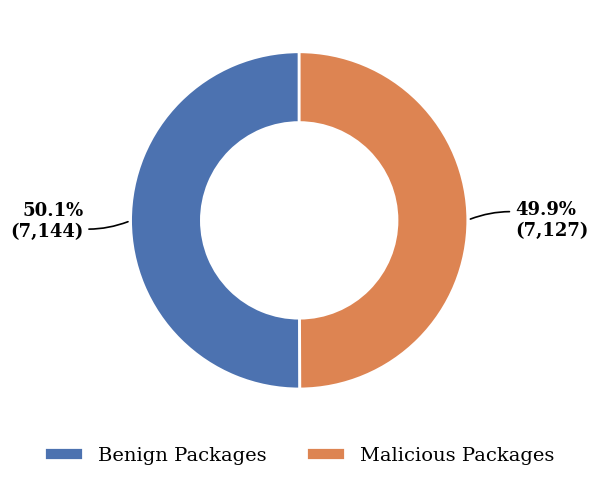

In [223]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Benign Packages", "Malicious Packages"]
sizes = [7144, 7127]
colors = ["#4C72B0", "#DD8452"]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14
})

fig, ax = plt.subplots(figsize=(6, 5), facecolor="white")

wedges, _ = ax.pie(
    sizes,
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2)
)

total = sum(sizes)

for i, w in enumerate(wedges):
    angle = (w.theta1 + w.theta2) / 2
    angle_rad = np.deg2rad(angle)

    # Point on outer edge of donut
    x = np.cos(angle_rad)
    y = np.sin(angle_rad)

    # Text position outside
    tx = 1.28 * np.cos(angle_rad)
    ty = 1.28 * np.sin(angle_rad)

    pct = sizes[i] / total * 100
    label = f"{pct:.1f}%\n({sizes[i]:,})"

    ha = "left" if tx > 0 else "right"

    ax.annotate(
        label,
        xy=(x, y),
        xytext=(tx, ty),
        ha=ha,
        va="center",
        fontsize=13,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="-",
            lw=1.2,
            color="black",
            connectionstyle="arc3,rad=0.2"
        )
    )

ax.legend(
    wedges,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

ax.set(aspect="equal")
plt.tight_layout()
plt.savefig("qutdv25_dataset_distribution_professional.png",
            dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

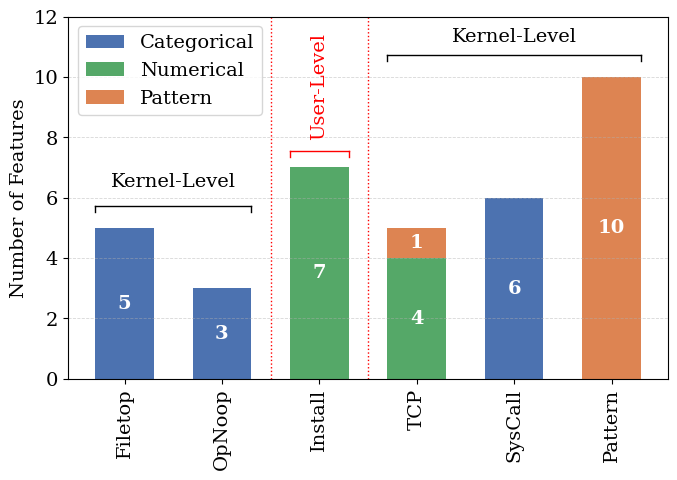

In [212]:
import matplotlib.pyplot as plt
import numpy as np

trace_types = [
    "Filetop",
    "OpNoop",
    "Install",
    "TCP",
    "SysCall",
    "Pattern"
]

categorical = [5, 3, 0, 0, 6, 0]
numerical   = [0, 0, 7, 4, 0, 0]
pattern     = [0, 0, 0, 1, 0, 10]

x = np.arange(len(trace_types))
width = 0.6

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14
})

fig, ax = plt.subplots(figsize=(7,5))

# Stacked bars
bars1 = ax.bar(x, categorical, width, label="Categorical", color="#4C72B0")
bars2 = ax.bar(x, numerical, width, bottom=categorical, label="Numerical", color="#55A868")
bars3 = ax.bar(x, pattern, width,
               bottom=np.array(categorical)+np.array(numerical),
               label="Pattern", color="#DD8452")

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(trace_types, rotation=90, ha='center')
ax.set_ylabel("Number of Features")

ax.set_ylim(0,12)

# subtle grid
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

# value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_y() + h/2,
                f"{int(h)}",
                ha="center",
                va="center",
                fontsize=14,
                color="white",
                fontweight="bold"
            )

# group separators
ax.axvline(1.5, color="red", linestyle=":", linewidth=1)
ax.axvline(2.5, color="red", linestyle=":", linewidth=1)

# -----------------------------
# Kernel-Level (left group)
# -----------------------------
y = 0.52

ax.annotate("Kernel-Level",
            xy=(0.5, y), xycoords=("data","axes fraction"),
            ha="center", va="bottom",
            fontsize=14)

# bracket just above text
y_line = y + 5.2

ax.plot([-0.3,1.3],[y_line,y_line], color='black', lw=1, clip_on=False)
ax.plot([-0.3,-0.3],[y_line-0.2,y_line+0.0], color='black', lw=1, clip_on=False)
ax.plot([1.3,1.3],[y_line-0.2,y_line+0.0], color='black', lw=1, clip_on=False)


# -----------------------------
# User-Level (middle)
# -----------------------------
y = 0.66

ax.annotate("User-Level",
            xy=(2, y), xycoords=("data","axes fraction"),
            ha="center", va="bottom",
            fontsize=14, rotation=90, color='red')

y_line = y + 6.9

ax.plot([1.7,2.3],[y_line,y_line], color='red', lw=1, clip_on=False)
ax.plot([1.7,1.7],[y_line-0.2,y_line+0.00], color='red', lw=1, clip_on=False)
ax.plot([2.3,2.3],[y_line-0.2,y_line+0.00], color='red', lw=1, clip_on=False)


# -----------------------------
# Kernel-Level (right group)
# -----------------------------
y = 0.92

ax.annotate("Kernel-Level",
            xy=(4, y), xycoords=("data","axes fraction"),
            ha="center", va="bottom",
            fontsize=14)

y_line = y + 9.8

ax.plot([2.7,5.3],[y_line,y_line], color='black', lw=1, clip_on=False)
ax.plot([2.7,2.7],[y_line-0.20,y_line+0.00], color='black', lw=1, clip_on=False)
ax.plot([5.3,5.3],[y_line-0.20,y_line+0.00], color='black', lw=1, clip_on=False)

# legend
ax.legend(frameon=True, loc="upper left", ncol=1)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)

plt.savefig("qutdv25_trace_sources.png", dpi=600, bbox_inches="tight")
plt.show()

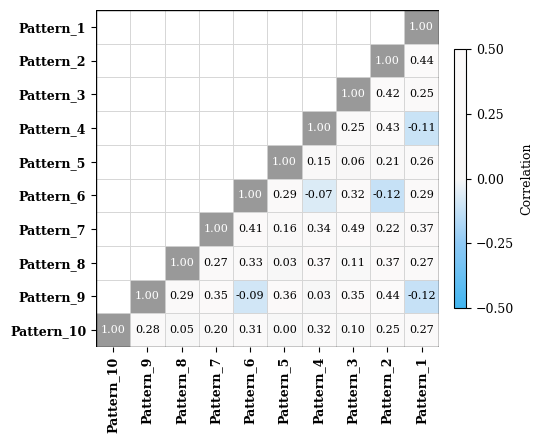

In [290]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.colors import LinearSegmentedColormap

labels = [
    "Pattern_1", "Pattern_2", "Pattern_3", "Pattern_4", "Pattern_5",
    "Pattern_6", "Pattern_7", "Pattern_8", "Pattern_9", "Pattern_10"
]

corr_values = [
    [1.00],
    [0.44, 1.00],
    [0.25, 0.42, 1.00],
    [-0.11, 0.43, 0.25, 1.00],
    [0.26, 0.21, 0.06, 0.15, 1.00],
    [0.29, -0.12, 0.32, -0.07, 0.29, 1.00],
    [0.37, 0.22, 0.49, 0.34, 0.16, 0.41, 1.00],
    [0.27, 0.37, 0.11, 0.37, 0.03, 0.33, 0.27, 1.00],
    [-0.12, 0.44, 0.35, 0.03, 0.36, -0.09, 0.35, 0.29, 1.00],
    [0.27, 0.25, 0.10, 0.32, 0.00, 0.31, 0.20, 0.05, 0.28, 1.00]
]

n = len(labels)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9
})

fig, ax = plt.subplots(figsize=(5.5,4.5))

# ---- Build custom colormap where the highest value is gray ----
colors_list = [
    (0.0, "#41b5f0"),   # blue
    (0.25, "#90caf5"),   # blue
    (0.5, "#f7f7f7"),   # white
    (1.0, "#fcfafa")    # gray at top
]

cmap = LinearSegmentedColormap.from_list("custom_corr", colors_list)

norm = colors.Normalize(vmin=-0.5, vmax=0.5)

# ---- Draw thin grid for all rectangles ----
for i in range(n):
    for j in range(n):
        rect = Rectangle(
            (j-0.5, i-0.5),
            1,1,
            facecolor="white",
            edgecolor="lightgray",
            linewidth=0.6
        )
        ax.add_patch(rect)

# ---- Draw triangular colored cells ----
for i in range(n):
    for j in range(len(corr_values[i])):

        value = corr_values[i][j]

        col = n-1-j
        row = i

        if i == j:
            facecolor = "#999"  # gray diagonal
        else:
            facecolor = cmap(norm(value))

        rect = Rectangle(
            (col-0.5, row-0.5),
            1,1,
            facecolor=facecolor,
            edgecolor="lightgray",
            linewidth=0.6
        )

        ax.add_patch(rect)

        # text color: white on diagonal, black otherwise
        if i == j:
            text_color = "white"
        else:
            text_color = "black"
        
        ax.text(
            col, row,
            f"{value:.2f}",
            ha='center',
            va='center',
            fontsize=8,
            color=text_color
        )

# ---- Bold outer border ----
ax.add_patch(Rectangle(
    (-0.5,-0.5),
    n,
    n,
    fill=False,
    edgecolor="black",
    linewidth=1.0
))

ax.set_xticks(range(n))
ax.set_yticks(range(n))

ax.set_xticklabels(labels[::-1], rotation=90, fontweight='bold')
ax.set_yticklabels(labels, fontweight='bold')

ax.set_xlim(-0.5, n-0.5)
ax.set_ylim(n-0.5, -0.5)

for spine in ax.spines.values():
    spine.set_visible(False)

# ---- Colorbar ----
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    fraction=0.035,
    pad=0.04
)

cbar.set_ticks([-0.5,-0.25,0,0.25,0.5])
cbar.set_label("Correlation", fontsize=9)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig("pattern_cor.png", dpi=600, bbox_inches="tight")
plt.show()